<a href="https://colab.research.google.com/github/johnsteeleprogramming/techconsulting/blob/DS_Assignment2/Assignment_2_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ASSIGNMENT 2 - MNIST

##LOAD LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as mvn
from google.colab import drive

print("--- Pandas version ---")
print(pd.__version__)
print("--- Seaborn ---")
print(sns.__version__)
print("--- MatPlotLib ---")
print(mpl.__version__)

--- Pandas version ---
2.2.2
--- Seaborn ---
0.13.2
--- MatPlotLib ---
3.10.0


##MOUNT DRIVE / LOAD PATH AND FILE

In [ ]:
mount_google_drive = False
path_training = '/content/MNIST_train.csv'

if mount_google_drive:
  drive.mount('/content/drive')
  path_training = '/content/drive/MyDrive/Classroom/Rebel AI/MNIST_train.csv'

##LOADING AND DESCRIBING THE TRAINING DATA

In [ ]:
mnist_training_data = pd.read_csv(path_training)

In [ ]:
mnist_training_data

,Unnamed: 0,index,labels,0,1,2,3,4,5,6,...,774,775,776,777,778,779,780,781,782,783
0,0,0,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,2,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,3,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,4,9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59995,59995,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,59996,59996,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,59997,59997,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,59998,59998,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
create_option = 0  # 0 - full; 1 - half;  2 - third; 3 - tenth

if create_option == 0:
  pass
elif create_option == 1:
  mnist_training_data = mnist_training_data[:30000]
  print(mnist_training_data.shape)
  mnist_training_data.to_csv('MNIST_train_half.csv', index=False)
elif create_option == 2:
  mnist_training_data = mnist_training_data[:20000]
  print(mnist_training_data.shape)
  mnist_training_data.to_csv('MNIST_train_third.csv', index=False)
elif create_option == 3:
  mnist_training_data = mnist_training_data[:6000]
  print(mnist_training_data.shape)
  mnist_training_data.to_csv('MNIST_train_tenth.csv', index=False)

In [ ]:
y_mnist_training_data = mnist_training_data['labels']

In [ ]:
y_mnist_training_data

,labels
0,5
1,0
2,4
3,1
4,9
...,...
59995,8
59996,3
59997,5
59998,6


In [ ]:
mnist_training_data.drop(mnist_training_data.columns[[0, 1, 2]], axis=1, inplace=True) # Drops only column 0 and column 1 and column 2

In [ ]:
mnist_training_data

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
mnist_training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 784 entries, 0 to 783
dtypes: int64(784)
memory usage: 358.9 MB


In [ ]:
y_mnist_training_data.info()

<class 'pandas.core.series.Series'>
RangeIndex: 60000 entries, 0 to 59999
Series name: labels
Non-Null Count  Dtype
--------------  -----
60000 non-null  int64
dtypes: int64(1)
memory usage: 468.9 KB


In [ ]:
mnist_training_data.count()

,0
0,60000
1,60000
2,60000
3,60000
4,60000
...,...
779,60000
780,60000
781,60000
782,60000


In [ ]:
y_mnist_training_data.count()

np.int64(60000)

In [ ]:
mnist_training_data.describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [ ]:
y_mnist_training_data.describe()

,labels
count,60000.000000
mean,4.453933
std,2.889270
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,9.000000


In [ ]:
mnist_training = mnist_training_data.to_numpy()

In [ ]:
y_mnist_training = y_mnist_training_data.to_numpy()

In [ ]:
from PIL import Image

def createImage(row_pixels, image_name):
  convert_array = np.array(row_pixels)
  arr_uint8 = convert_array.astype(np.uint8)
  matrix_array = np.reshape(arr_uint8, (28, 28))
  new_image = Image.fromarray(matrix_array)
  #new_image.save(image_name + '.png')
  plt.imshow(new_image)
  plt.axis('off')
  plt.show()


5


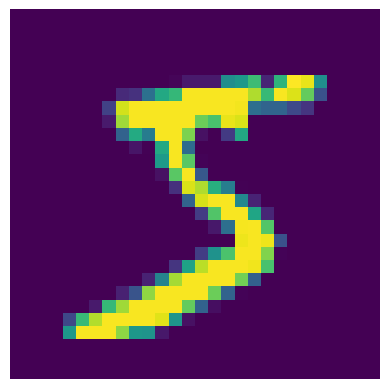

0


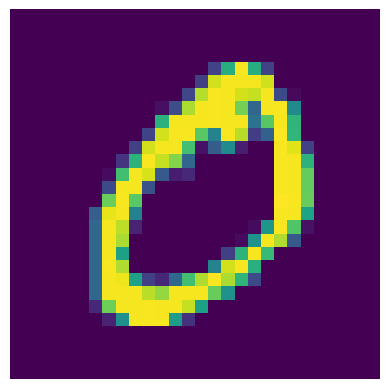

4


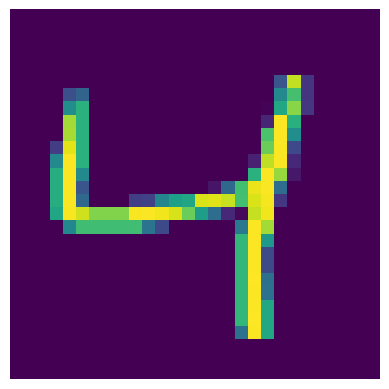

1


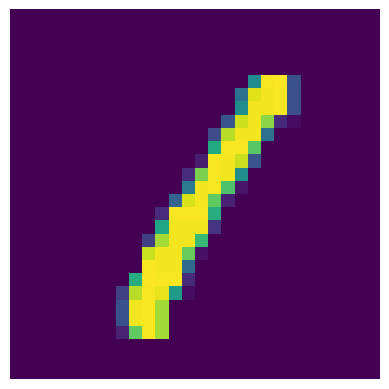

In [ ]:
show_images = True

if show_images:
  number_rows_to_image = 4
  for i in range(number_rows_to_image):
    row = mnist_training[i,:]
    image_name = 'image_' + str(i)
    print(y_mnist_training[i])
    createImage(row, image_name)

##ANALYZING THE MNIST DATA

###GAUSS NAIVE BAYES

####FINDING HIGHEST EPSILON ACCURACY

In [ ]:
class GaussNaiveBayes():

  def fit(self, X, y, epsilon = 1e-3):
    self.likelihoods = dict()
    self.priors = dict()
    y = y.flatten() if y.ndim > 1 else y
    self.K = set(y.astype(int))
    for k in self.K:
      X_k = X[y==k, :]
      self.likelihoods[k] = {"mean": X_k.mean(axis=0), "cov": X_k.var(axis=0) + epsilon}
      self.priors[k] = len(X_k)/len(X)

  def predict(self, X):
    N, D = X.shape
    P_hat = np.zeros((N, len(self.K)))
    for k, l in self.likelihoods.items():
      P_hat[:,k] = mvn.logpdf(X, l["mean"], l["cov"]) + np.log(self.priors[k])
    return P_hat.argmax(axis=1)

In [ ]:
def accuracy(y, y_hat):
  return np.mean(y==y_hat)

In [ ]:
gnb = GaussNaiveBayes()

In [ ]:
epsilon_results = dict()
#epsilon_attempts = [1e-5, 1e-3, 0.1, 1, 10, 100, 1000, 10000]
epsilon_attempts = [1000]

In [ ]:
print("--- MOST ACCURATE EPSILON FOR GAUSS NAIVE BAYES ---")
print("--- NOTE: AT 1e-6 THROWS ERROR: ---")
print("\tWhen `allow_singular is False`, the input matrix must be symmetric positive definite.")
calculate_through_epsilon_attempts = True
if calculate_through_epsilon_attempts:
  for epsilon in epsilon_attempts:
    print(epsilon)
    gnb.fit(mnist_training, y_mnist_training, epsilon)
    y_hat_mnist_training = gnb.predict(mnist_training)
    acc = accuracy(y_mnist_training, y_hat_mnist_training)
    epsilon_results.update({epsilon : acc})
  print(epsilon_results)

--- MOST ACCURATE EPSILON FOR GAUSS NAIVE BAYES ---
--- NOTE: AT 1e-6 THROWS ERROR: ---
	When `allow_singular is False`, the input matrix must be symmetric positive definite.
1000
{1000: np.float64(0.80235)}


In [ ]:
print("--- HIGHEST ACCURACY WITH EPSILON AT 1000 ---")
#max_value = max(epsilon_results.values())
#epsilon = [key for key, value in epsilon_results.items() if value == max_value]
#print(str(epsilon[0]) + " : " + str(epsilon_results[epsilon[0]]))

--- HIGHEST ACCURACY WITH EPSILON AT 1000 ---


###GAUSS NON-NAIVE BAYES

In [ ]:
class GaussBayes():

  def fit(self, X, y, epsilon = 1e-3):
    print("GB epsilon: " + str(epsilon))
    self.likelihoods = dict()
    self.priors = dict()
    y = y.flatten() if y.ndim > 1 else y
    self.K = set(y.astype(int))

    for k in self.K:
      X_k=X[y==k,:]
      N_k,D = X_k.shape
      mu_k = X_k.mean(axis = 0)

      self.likelihoods[k] = {"mean": X_k.mean(axis=0),
                             "cov": (1/(N_k-1))*np.matmul((X_k-mu_k).T,X_k-mu_k)+epsilon*np.identity(D)}
      self.priors[k] = len(X_k)/len(X)

  def predict(self, X):
    N, D = X.shape
    P_hat = np.zeros((N, len(self.K)))
    for k, l in self.likelihoods.items():
      P_hat[:,k] = mvn.logpdf(X, l["mean"], l["cov"])+np.log(self.priors[k])
    return P_hat.argmax(axis=1)

In [ ]:
gb = GaussBayes()
gb.fit(mnist_training, y_mnist_training)

GB epsilon: 0.001


In [ ]:
epsilon_attempts = [1e-3, 0.1, 10, 100, 1000, 5000]
epsilon_attempts = [10000]
results = dict()
if True:
  for attempt in epsilon_attempts:
    #print("X shape: " + str(mnist_training.shape))
    #print("Y shape: " + str(y_mnist_training.shape))
    #print("Epsilon: " + str(attempt))
    gb.fit(mnist_training, y_mnist_training, attempt)
    y_hat_mnist_training = gb.predict(mnist_training)
    acc = accuracy(y_mnist_training, y_hat_mnist_training)
    results.update({attempt: acc})
print(results)
print("{0.001: np.float64(0.78565), \n0.1: np.float64(0.83715), \n10: np.float64(0.9025333333333333), \n100: np.float64(0.9366166666666667), \n1000: np.float64(0.95805), \n5000: np.float64(0.9572333333333334)}")

GB epsilon: 10000
{10000: np.float64(0.9496666666666667)}
{0.001: np.float64(0.78565), 
0.1: np.float64(0.83715), 
10: np.float64(0.9025333333333333), 
100: np.float64(0.9366166666666667), 
1000: np.float64(0.95805), 
5000: np.float64(0.9572333333333334)}


###KNN

In [ ]:
print(mnist_training)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
class KNNClassifier():
  def fit(self, X, y):
    self.X = X
    self.y = y.astype(int).flatten()

  def predict(self, X, K, epsilon = 1e-3):
    N = len(X)
    y_hat = np.zeros(N)
    X = X.astype(np.float64)

    for i in range(N):
      dist2 = np.sum((self.X-X[i])**2, axis=1)
      idxt = np.argsort(dist2)[:K]
      gamma_k = 1/np.sqrt(dist2[idxt].astype(np.float64) + epsilon)  # epsilon can be outside of sqrt
      y_hat[i] = np.bincount(self.y[idxt], weights=gamma_k).argmax()

    return y_hat

In [ ]:
knn = KNNClassifier()

In [ ]:
knn.fit(mnist_training,y_mnist_training)

In [ ]:
#y_hat_mnist_training = knn.predict(mnist_training, K=20)

In [ ]:
#accuracy(y_mnist_training, y_hat_mnist_training)